In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Load the data
df = pd.read_csv("../data/raw_data/ethiopia.csv") # Ensure you put your CSV in the data/ folder!

# 1. Immediate Clean: Replace NASA's -999 sentinel with NaN [cite: 114]
df.replace(-999, np.nan, inplace=True)

# 2. Date Conversion: Turn YEAR and DOY into a real date [cite: 111]
df['Date'] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df['Month'] = df['Date'].dt.month # Needed for seasonal analysis [cite: 112]

# 3. Add Country Column [cite: 110]
df['Country'] = 'Ethiopia'

df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month,Country
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00,2015-01-01,1,Ethiopia
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,2015-01-02,1,Ethiopia
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,2015-01-03,1,Ethiopia
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,2015-01-04,1,Ethiopia
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,2015-01-05,1,Ethiopia


In [17]:
###Data cleaning (sentinels and duplicates
            
# 1. Replace NASA's -999 sentinel with NaN [cite: 114, 398]
df.replace(-999, np.nan, inplace=True)

# 2. Handle duplicates [cite: 116]
duplicate_count = df.duplicated().sum()
print(f"Duplicates found: {duplicate_count}")
df.drop_duplicates(inplace=True)

# 3. Missing Value Report [cite: 118]
missing_pct = (df.isna().sum() / len(df)) * 100
print("\nMissing Values Percentage:")
print(missing_pct[missing_pct > 0])

Duplicates found: 0

Missing Values Percentage:
Series([], dtype: float64)


In [3]:
###statistical profiling

# Summary statistics for numeric columns [cite: 117]
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,16.06850,23.199175,10.227544,12.971631,3.633795,68.408588,1.979998,3.575246,77.037529,9.697724,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,10.03000,15.650000,1.170000,3.560000,0.000000,14.420000,0.460000,0.790000,76.360000,2.120000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,14.82000,21.110000,8.417500,9.830000,0.020000,59.030000,1.407500,2.720000,76.980000,8.070000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,16.04000,22.740000,10.990000,13.030000,0.820000,71.120000,1.970000,3.530000,77.040000,10.270000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,17.36000,25.170000,12.220000,16.020000,4.580000,80.802500,2.480000,4.370000,77.100000,11.710000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,21.53000,30.930000,15.680000,23.240000,82.300000,91.930000,4.130000,7.490000,77.370000,13.520000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.89805,2.751471,2.607256,3.821239,6.289061,14.735838,0.689093,1.123721,0.099484,2.362462,NaN,3.477046


In [14]:
### Outlier detection( z-scores)

# Flag rows where |Z| > 3 for key climate variables [cite: 121]
cols_to_check = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M']
outlier_report = {}

for col in cols_to_check:
    z_scores = np.abs(stats.zscore(df[col], nan_policy='omit'))
    outlier_report[col] = (z_scores > 3).sum()

print("Outlier counts (|Z| > 3):")
print(outlier_report)

# Handling strategy: We retain outliers as they often represent 
# actual extreme weather events critical for COP32[cite: 123].

Outlier counts (|Z| > 3):
{'T2M': np.int64(3), 'T2M_MAX': np.int64(0), 'T2M_MIN': np.int64(18), 'PRECTOTCORR': np.int64(95), 'RH2M': np.int64(13), 'WS2M': np.int64(3)}


<BarContainer object of 135 artists>

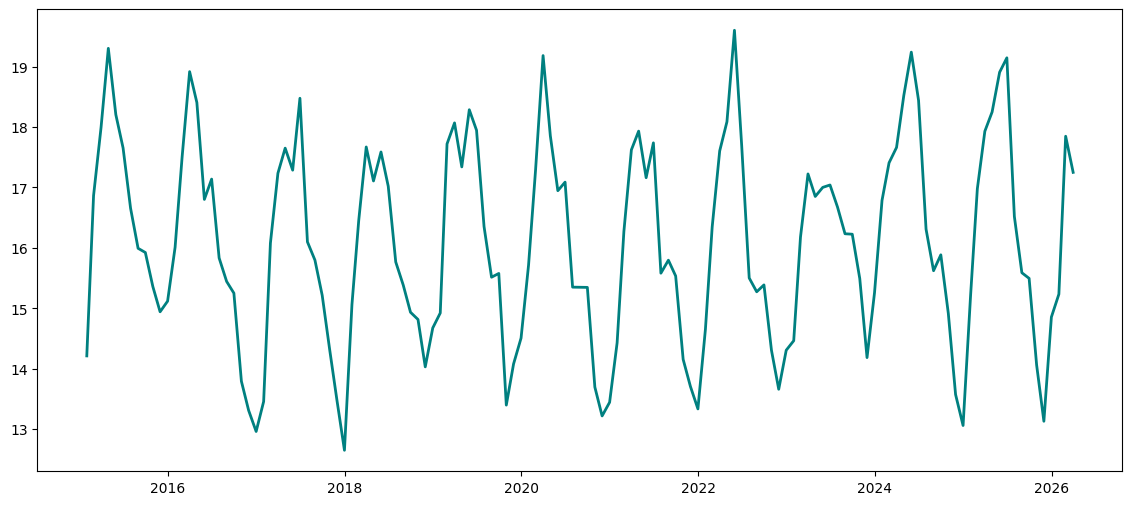

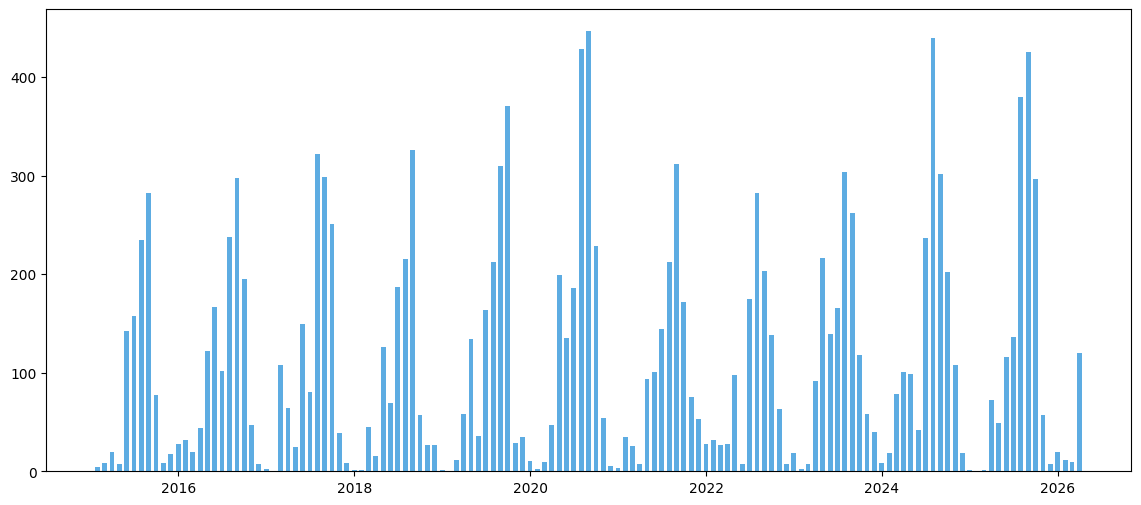

In [15]:
### Time series analysis
# 1. Plot monthly average Temperature (T2M)
plt.figure(figsize=(14, 6))

# Change 'M' to 'ME' (Month End)
monthly_temp = df.set_index('Date')['T2M'].resample('ME').mean() 

plt.plot(monthly_temp.index, monthly_temp.values, color='teal', linewidth=2)

# ... (the rest of your plotting code)

# 2. Plot monthly total Precipitation (PRECTOTCORR)
plt.figure(figsize=(14, 6))
# Change 'M' to 'ME' here as well
monthly_precip = df.set_index('Date')['PRECTOTCORR'].resample('ME').sum()
plt.bar(monthly_precip.index, monthly_precip.values, width=20, color='#3498db', alpha=0.8)
# ... (the rest of your plotting code)

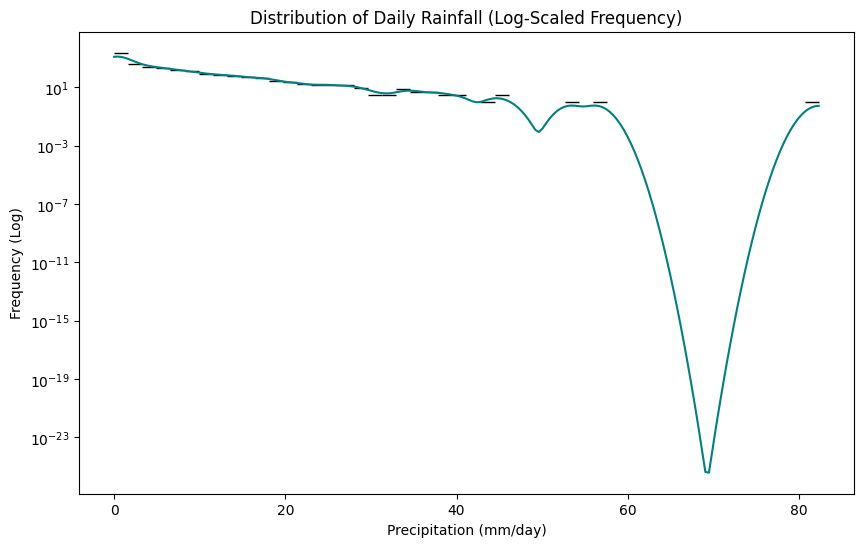

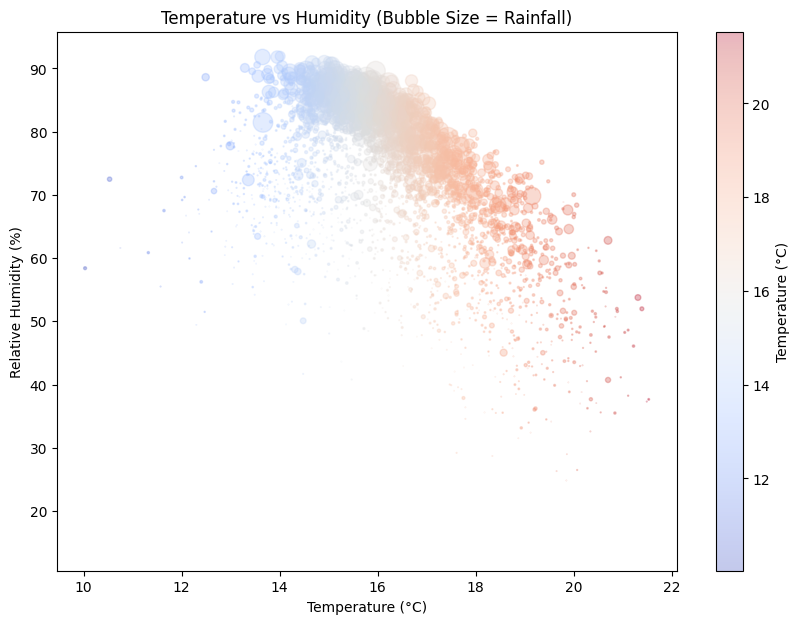

In [11]:
### distribution analysis 

# 1. Histogram of Precipitation (using log scale as suggested for skewed data) 
plt.figure(figsize=(10, 6))
import seaborn as sns # Standard alias
sns.histplot(df['PRECTOTCORR'], bins=50, kde=True, color='teal', log_scale=(False, True))
plt.title("Distribution of Daily Rainfall (Log-Scaled Frequency)", fontsize=12)
plt.xlabel("Precipitation (mm/day)")
plt.ylabel("Frequency (Log)")
plt.show()

# 2. Bubble Chart: T2M vs. RH2M (Relative Humidity) [cite: 137]
# Size of the bubble represents the amount of rainfall (PRECTOTCORR)
plt.figure(figsize=(10, 7))
plt.scatter(df['T2M'], df['RH2M'], s=df['PRECTOTCORR']*5, alpha=0.3, c=df['T2M'], cmap='coolwarm')
plt.colorbar(label='Temperature (°C)')
plt.title("Temperature vs Humidity (Bubble Size = Rainfall)", fontsize=12)
plt.xlabel("Temperature (°C)")
plt.ylabel("Relative Humidity (%)")
plt.show()

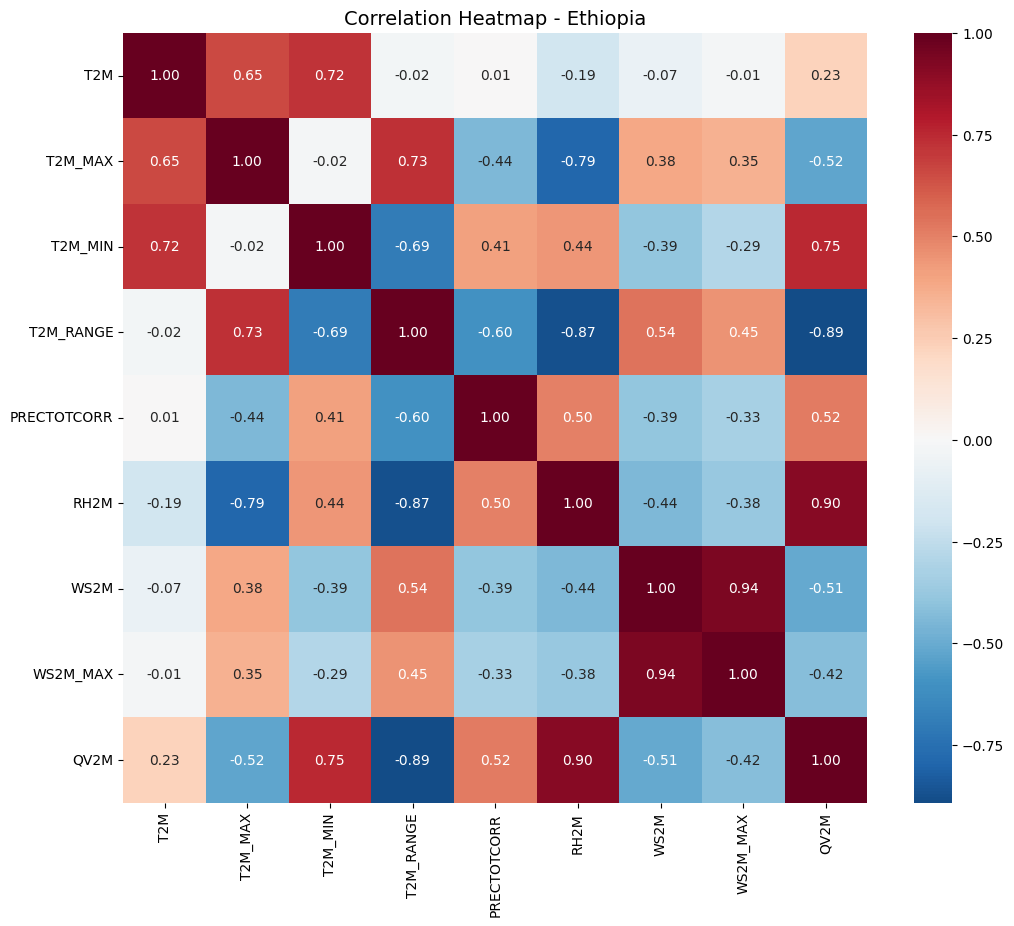

In [40]:
###Correlation analysis

# Create a correlation heatmap [cite: 132]
plt.figure(figsize=(12, 10))
# Select only numeric columns for correlation
cols = ['T2M', 'T2M_MAX', 'T2M_MIN'
, 'T2M_RANGE', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX', 'QV2M']
correlation_matrix = df[cols].corr()

sns.heatmap(correlation_matrix, annot=True, cmap='RdBu_r', center=0, fmt='.2f')
plt.title(f"Correlation Heatmap - {df['Country'].iloc[0]}", fontsize=14)
plt.show()

In [13]:
# Create the clean filename based on the country
country_name = "ethiopia" # Update this for each notebook
output_path = f"../data/cleaned_data/ethiopia_clean.csv"

# Export to the data folder
df.to_csv(output_path, index=False)
print(f"Successfully saved")



Successfully saved
